<a href="https://colab.research.google.com/github/skyline554/-1/blob/main/%EA%B3%BC%EC%A0%9C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 과제1

1) n = 100으로 놓고
1. X ~ N(0,1), Y~N(0,1)을 각각 생성하시오.
2. Z=X/Y를 계산하시오.
3. Z의 히스토그램을 그려보시오.
4. 위의 분포를 코시(Cauchy) 분포라고 하는데, 코시 분포의 특징을 정리해보시오.

2) 요구사항


표본크기 n=5,10,50,100,500,1000에 대해 실험하시오.


각 n마다 코시분포에서 표본을 1000번 반복 추출하시오.


매 반복마다 표본평균을 계산하시오.


각 표본크기별 표본평균의 분포를 그래프 또는 박스플롯으로 나타내시오.


같은 실험을 표준정규분포에 대해서도 수행하여 비교하시오.

In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 92.1 MB/s eta 0:00:00


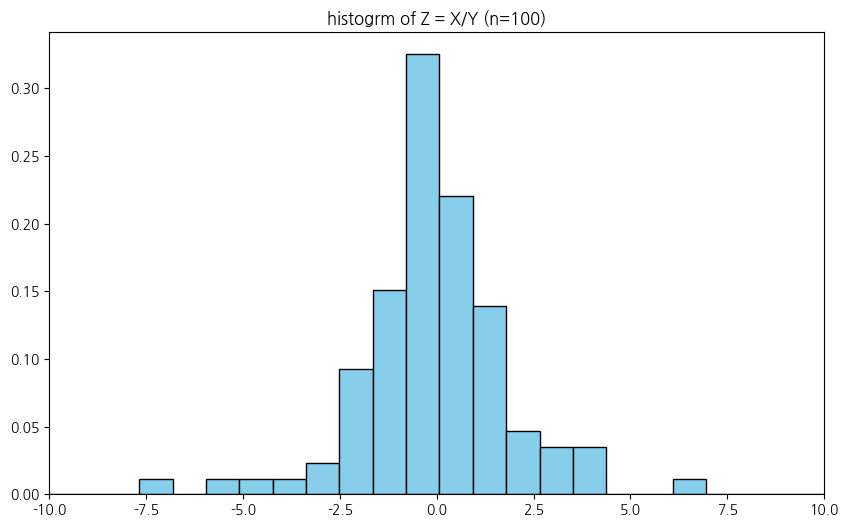

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import koreanize_matplotlib

# n를 100으로 놓고
n = 100

# X~N(0,1), Y~N(0,1)을 각각 생성
X = np.random.normal(0, 1, n)
Y = np.random.normal(0, 1, n)

# Z를 X/Y로 계산
Z = X / Y

plt.figure(figsize=(10, 6))
plt.hist(Z, bins=50, color='skyblue', edgecolor='black', density=True)
plt.title('histogrm of Z = X/Y (n=100)')
plt.xlim(-10,10)
plt.show()



## 코시분포의 특징 정리

- 평균과 분산의 부재: 적분값이 수렵하지 않고 발산하기 때문에 기대값 평균과 분산이 정의되지 않는다.

- 두꺼운 꼬리: 정규분포와 모양은 비슷하지만, 양 끝의 꼬리가 훨씬 두껍다.

- 안정적 분포: 코시분포를 따르는 변수들의 평균을 내도 여전히 코시 분포를 유지하며, 정규분포로 수렴하지 않는다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.1 MB/s eta 0:00:00


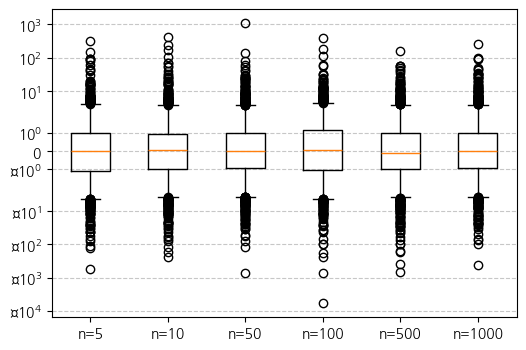

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy

!pip install koreanize-matplotlib
import koreanize_matplotlib


sample_size =[5, 10, 50, 100, 500, 1000]
iterations = 1000
result = []

# 각 n에 대해 1000번 반복 추출하여 표본평균 계산
for n in sample_size:
    means = []
    for _ in range(iterations):
        sample = np.random.standard_cauchy(n)
        means.append(np.mean(sample))
    result.append(means)

#박스플롯 시각화
plt.figure(figsize=(6, 4))
plt.boxplot(result, tick_labels=[f"n={n}" for n in sample_size])

plt.yscale('symlog')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2550/2235204834.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(cauchy_means, labels=[f"n={n}" for n in sample_sizes])
/tmp/ipykernel_2550/2235204834.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(normal_means, labels=[f"n={n}" for n in sample_sizes])


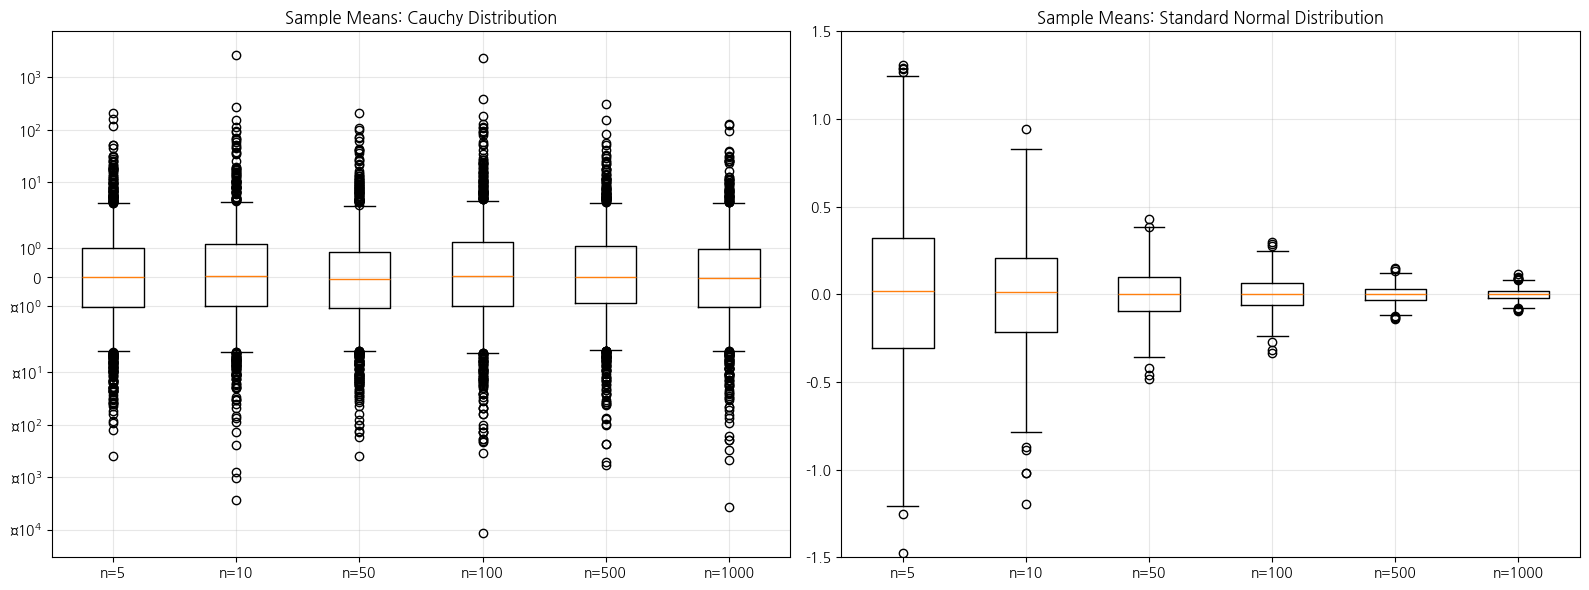

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sample_sizes = [5, 10, 50, 100, 500, 1000]
iterations = 1000

# 데이터를 담을 리스트
cauchy_means = []
normal_means = []

for n in sample_sizes:
    c_means = [np.mean(np.random.standard_cauchy(n)) for _ in range(iterations)]
    n_means = [np.mean(np.random.normal(0, 1, n)) for _ in range(iterations)]

    cauchy_means.append(c_means)
    normal_means.append(n_means)

# 시각화 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 코시 분포 표본평균 박스플롯
ax1.boxplot(cauchy_means, labels=[f"n={n}" for n in sample_sizes])
ax1.set_title("Sample Means: Cauchy Distribution")
ax1.set_yscale('symlog')
ax1.grid(True, alpha=0.3)

# 2. 표준정규분포 표본평균 박스플롯
ax2.boxplot(normal_means, labels=[f"n={n}" for n in sample_sizes])
ax2.set_title("Sample Means: Standard Normal Distribution")
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()